Pretrained ResNet18 loaded
Parameters: 11,689,512


100%|██████████| 170M/170M [1:21:56<00:00, 34.7kB/s] 


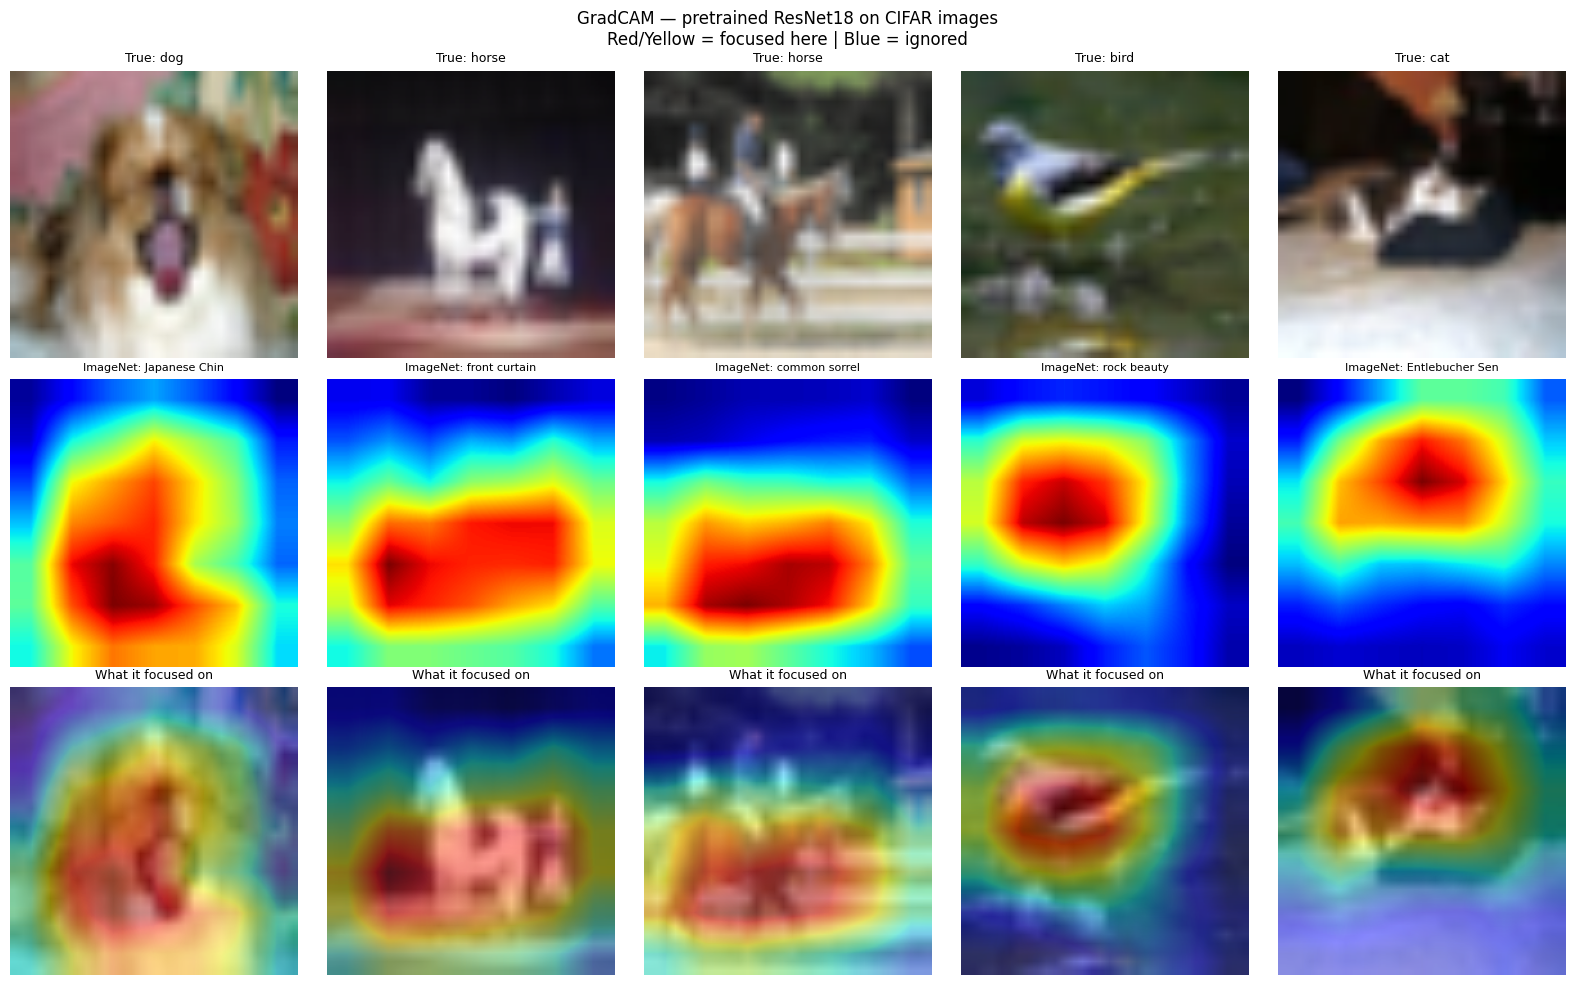

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# ── Pretrained ResNet — no training needed ────────────────
# Pretrained on 1.2M ImageNet images
# Already knows edges, shapes, textures — perfect for GradCAM demo
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()
print("Pretrained ResNet18 loaded")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


# ── GradCAM ───────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(
            self._save_activation)
        target_layer.register_full_backward_hook(
            self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam     = (weights * self.activations).sum(
                   1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, x.shape[2:],
                                mode='bilinear',
                                align_corners=False)
        cam     = cam.squeeze().numpy()
        cam     = (cam - cam.min()) / (
                   cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# ── ImageNet class names for pretrained model ─────────────
# These are the 1000 ImageNet classes
# We'll filter for CIFAR-relevant ones
import urllib.request, json

url = ("https://raw.githubusercontent.com/anishathalye"
       "/imagenet-simple-labels/master/imagenet-simple"
       "-labels.json")
with urllib.request.urlopen(url) as r:
    imagenet_labels = json.loads(r.read())


# ── Loading CIFAR test images ────────────────────────────────
# Using larger size so GradCAM is clearer
transform = transforms.Compose([
    transforms.Resize(224),          # ResNet native size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

DATA_PATH = r"C:\Users\Hp\.vscode\Journey to the BEST\Week 5"

test_data   = datasets.CIFAR10(DATA_PATH, train=False,
                                transform=transform,
                                download=True)
test_loader = DataLoader(test_data, batch_size=32,
                          shuffle=True)

cifar_classes = ['airplane','automobile','bird','cat',
                 'deer','dog','frog','horse','ship','truck']


# ── Running GradCAM ───────────────────────────────────────────
gradcam = GradCAM(model, model.layer4[-1])

images, labels = next(iter(test_loader))

fig, axes = plt.subplots(3, 5, figsize=(16, 10))

for i in range(5):
    img = images[i:i+1]

    cam, pred_idx = gradcam.generate(img)
    pred_label    = imagenet_labels[pred_idx]

    # Denormalising
    img_show = img[0].permute(1, 2, 0).numpy()
    img_show = img_show * [0.229, 0.224, 0.225]
    img_show = img_show + [0.485, 0.456, 0.406]
    img_show = np.clip(img_show, 0, 1)

    true_label = cifar_classes[labels[i]]

    # Row 1 — original
    axes[0, i].imshow(img_show)
    axes[0, i].set_title(f"True: {true_label}", fontsize=9)
    axes[0, i].axis('off')

    # Row 2 — heatmap only
    axes[1, i].imshow(cam, cmap='jet')
    axes[1, i].set_title(f"ImageNet: {pred_label[:15]}",
                          fontsize=8)
    axes[1, i].axis('off')

    # Row 3 — overlay
    axes[2, i].imshow(img_show)
    axes[2, i].imshow(cam, cmap='jet', alpha=0.45)
    axes[2, i].set_title('What it focused on', fontsize=9)
    axes[2, i].axis('off')

plt.suptitle(
    'GradCAM — pretrained ResNet18 on CIFAR images\n'
    'Red/Yellow = focused here | Blue = ignored',
    fontsize=12
)
plt.tight_layout()
plt.show()